**Tugas 3-WEB SCRAPPING**

In [2]:
import requests
from bs4 import BeautifulSoup

In [3]:
app_id = 413150  # ini id nya menyesuaikan game yg dipilih

url = f'https://store.steampowered.com/app/{app_id}/'
page = requests.get(url, cookies={'birthtime':'568022401'})
# cookie 'birthtime' buat lewatin age-check klo gamenya ada rating dewasa
page

<Response [200]>

Pada bagian ini kita menentukan ID game yang akan diambil dari Steam. Karena game yang dipilih adalah Stardew Valley, maka digunakan app_id = 413150. Setelah itu, URL Steam dibuat berdasarkan ID tersebut dan halaman game diakses menggunakan requests. Cookie birthtime digunakan untuk melewati age-check apabila halaman game memerlukannya.

In [4]:
soup = BeautifulSoup(page.text, 'html.parser')
soup

<!DOCTYPE html>

<html class="responsive DesktopUI" lang="en">
<head>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="width=device-width,initial-scale=1" name="viewport"/>
<meta content="#171a21" name="theme-color"/>
<title>Save 30% on Stardew Valley on Steam</title>
<link href="/favicon.ico" rel="shortcut icon" type="image/x-icon"/>
<link href="https://store.fastly.steamstatic.com/public/shared/css/motiva_sans.css?v=YzJgj1FjzW34&amp;l=english&amp;_cdn=fastly" rel="stylesheet" type="text/css"/>
<link href="https://store.fastly.steamstatic.com/public/shared/css/shared_global.css?v=sat0mVAiy9IE&amp;l=english&amp;_cdn=fastly" rel="stylesheet" type="text/css"/>
<link href="https://store.fastly.steamstatic.com/public/shared/css/buttons.css?v=BZhNEtESfYSJ&amp;l=english&amp;_cdn=fastly" rel="stylesheet" type="text/css"/>
<link href="https://store.fastly.steamstatic.com/public/css/v6/store.css?v=xtQBq3cs1dB0&amp;l=english&amp;_cdn=fastly" rel="stylesheet" ty

Di bagian ini kita mengambil isi halaman Steam yang sudah diakses sebelumnya, kemudian menggunakan BeautifulSoup untuk membaca dan mengambil elemen HTML tertentu dari halaman tersebut.

In [5]:
soup.title

<title>Save 30% on Stardew Valley on Steam</title>

In [ ]:
soup.find('div', {'id':'appHubAppName'})

<div aria-level="1" class="apphub_AppName" id="appHubAppName" role="heading">Stardew Valley</div>

In [ ]:
soup.find('div', {'id':'appHubAppName'}).text

'Stardew Valley'

In [ ]:
soup.find('div', {'id':'game_area_description'}).text

"\nAbout This Game\n\t\t\t\t\t\t\tStardew Valley is an open-ended country-life RPG!  You've inherited your grandfather's old farm plot in Stardew Valley. Armed with hand-me-down tools and a few coins, you set out to begin your new life. Can you learn to live off the land and turn these overgrown fields into a thriving home? It won't be easy. Ever since Joja Corporation came to town, the old ways of life have all but disappeared. The community center, once the town's most vibrant hub of activity, now lies in shambles. But the valley seems full of opportunity. With a little dedication, you might just be the one to restore Stardew Valley to greatness!Features Turn your overgrown field into a lively farm!   Raise animals, grow crops, start an orchard, craft useful machines, and more! You'll have plenty of space to create the farm of your dreams. 8 Player Farming! Invite 1-7 players to join you in the valley online! Players can work together to build a thriving farm, share resources, and im

In [ ]:
soup.find('div', {'class':'glance_tags popular_tags'})

<div class="glance_tags popular_tags" data-appid="413150" data-panel='{"flow-children":"row"}'>
<a class="app_tag" href="https://store.steampowered.com/tags/en/Farming%20Sim/?snr=1_5_9__409" style="display: none;">
												Farming Sim												</a><a class="app_tag" href="https://store.steampowered.com/tags/en/Pixel%20Graphics/?snr=1_5_9__409" style="display: none;">
												Pixel Graphics												</a><a class="app_tag" href="https://store.steampowered.com/tags/en/Multiplayer/?snr=1_5_9__409" style="display: none;">
												Multiplayer												</a><a class="app_tag" href="https://store.steampowered.com/tags/en/Life%20Sim/?snr=1_5_9__409" style="display: none;">
												Life Sim												</a><a class="app_tag" href="https://store.steampowered.com/tags/en/RPG/?snr=1_5_9__409" style="display: none;">
												RPG												</a><a class="app_tag" href="https://store.steampowered.com/tags/en/Relaxing/?snr=1_5_9__409" style="display: none;">
												Relaxing

In [ ]:
tags = soup.find('div', {'class':'glance_tags popular_tags'})
for i in tags.find_all('a'):
  print(i.text.strip())

Farming Sim
Pixel Graphics
Multiplayer
Life Sim
RPG
Relaxing
Simulation
Agriculture
Crafting
Sandbox
Indie
Building
Open World
Casual
Singleplayer
2D
Dating Sim
Cute
Great Soundtrack
Fishing


Diambil dari https://partner.steamgames.com/doc/store/getreviews

In [6]:
url_api = f'https://store.steampowered.com/appreviews/{app_id}'
api_request = requests.get(url_api, params={'json':1})
api_request

<Response [200]>

Pada bagian ini kita membuat URL API Steam menggunakan app_id dari game yang dipilih. Kemudian requests.get() digunakan untuk mengirim permintaan ke API Steam agar mendapatkan data review dalam format JSON. Hasil permintaan tersebut kemudian ditampilkan.

In [7]:
api_request_json = api_request.json()
api_request_json

{'success': 1,
 'query_summary': {'num_reviews': 20,
  'review_score': 9,
  'review_score_desc': 'Overwhelmingly Positive',
  'total_positive': 390553,
  'total_negative': 4422,
  'total_reviews': 394975},
 'reviews': [{'recommendationid': '235340353',
   'author': {'steamid': '76561198055688257',
    'personaname': 'DoubleCheeks McGee',
    'persona_status': 'in-game',
    'profile_url': 'https://steamcommunity.com/profiles/76561198055688257/',
    'num_games_owned': 62,
    'num_reviews': 1,
    'playtime_forever': 63359,
    'playtime_last_two_weeks': 0,
    'playtime_at_review': 63332,
    'last_played': 1789493140,
    'avatar': 'e6b7203c6ab91dea82aa7ce54c275a2dd66520f9'},
   'language': 'english',
   'review': 'I love, love, love this game- have loved it since release and will continue to love it for as long as I breathe. I never hesitate to purchase a new copy when I adopt a new gaming platform- when I was thru-hiking on the Appalachian Trail I would play this offline in hostels

Pada bagian ini hasil dari permintaan API diubah menjadi format JSON menggunakan .json(), sehingga data review dapat diakses dan diolah dalam Python. Setelah itu, data JSON ditampilkan untuk melihat isi respons dari API.

In [8]:
api_request_json.get('reviews')

[{'recommendationid': '235340353',
  'author': {'steamid': '76561198055688257',
   'personaname': 'DoubleCheeks McGee',
   'persona_status': 'in-game',
   'profile_url': 'https://steamcommunity.com/profiles/76561198055688257/',
   'num_games_owned': 62,
   'num_reviews': 1,
   'playtime_forever': 63359,
   'playtime_last_two_weeks': 0,
   'playtime_at_review': 63332,
   'last_played': 1789493140,
   'avatar': 'e6b7203c6ab91dea82aa7ce54c275a2dd66520f9'},
  'language': 'english',
  'review': 'I love, love, love this game- have loved it since release and will continue to love it for as long as I breathe. I never hesitate to purchase a new copy when I adopt a new gaming platform- when I was thru-hiking on the Appalachian Trail I would play this offline in hostels and in town stops on my phone, and fear I will never tire of it.\n\nDespite having sunk (across varying platforms, what I assume to be) 1500+ hours into this masterpiece, I have not yet reached perfection- I am in no rush at all, 

Pada bagian ini kita mengambil bagian reviews dari data JSON. Bagian tersebut berisi kumpulan data review yang diberikan oleh pengguna Steam.

In [10]:
for i in api_request_json.get('reviews'):
  print(i.get('review'))

I love, love, love this game- have loved it since release and will continue to love it for as long as I breathe. I never hesitate to purchase a new copy when I adopt a new gaming platform- when I was thru-hiking on the Appalachian Trail I would play this offline in hostels and in town stops on my phone, and fear I will never tire of it.

Despite having sunk (across varying platforms, what I assume to be) 1500+ hours into this masterpiece, I have not yet reached perfection- I am in no rush at all, and am a little sad that I am nearly there now- however, with the new update coming later this year, I have no worries or hesitations at all when it comes to beginning a new farm and starting the journey from the beginning once more. 

Absolutely recommend, my all-time favorite RPG, and I am always filled with so much joy and absolute enthusiasm when it comes to future updates. May be the perfect game.
Usually this is great for relaxation, chilling, and building/growing on your farm... except 

Pada bagian ini kita melakukan perulangan untuk mengambil setiap data review yang terdapat dalam reviews. i.get('review') digunakan untuk mengambil isi teks review dari setiap data, kemudian hasilnya ditampilkan satu per satu.

Algoritma

In [9]:
reviews = []
voted_up = []

cursor = '*'
for page in range(1, 11):
  api_request = requests.get(url_api, params={'json':1, 'filter':'recent', 'language':'indonesian', 'cursor':cursor, 'num_per_page':100})
  data = api_request.json()
  scrap = data.get('reviews')

  for i in scrap:
    reviews.append(i.get('review'))
    voted_up.append(i.get('voted_up'))

  cursor = data.get('cursor')

Pada bagian ini kita menyiapkan beberapa variabel untuk menyimpan hasil scraping, yaitu reviews untuk menyimpan isi review dan voted_up untuk menyimpan status rekomendasi dari setiap review, sedangkan cursor digunakan sebagai penanda untuk mengambil data review berikutnya. Selanjutnya, dilakukan perulangan sebanyak 10 kali untuk mengambil review secara bertahap melalui API, dengan filter review terbaru (recent), bahasa Indonesia, dan maksimal 100 review dalam setiap permintaan. cursor digunakan agar pengambilan data dapat dilanjutkan ke kumpulan review berikutnya.

In [11]:
len(reviews), len(voted_up)

(359, 359)

Pada bagian ini kita menghitung jumlah data yang berhasil dikumpulkan pada reviews dan voted_up. Hal ini digunakan untuk memastikan jumlah keduanya sesuai.

In [12]:
import pandas as pd
df = pd.DataFrame(
    {'Reviews':reviews,
     'Voted_up':voted_up
     })
df

,Reviews,Voted_up
0,if you're looking for cozy game like harverst ...,True
1,Seru banget,True
2,game bagus,True
3,candu,True
4,asik,True
...,...,...
354,Jadi Berasa Tua (:,True
355,i love my wife haley,True
356,Mantab,True
357,main langsung jadi autis,True


Pada bagian ini kita menggunakan Pandas untuk membuat DataFrame dari data yang sudah dikumpulkan. Kolom Reviews berisi teks review, sedangkan Voted_up berisi status rekomendasi dari pengguna. Setelah itu, DataFrame ditampilkan untuk melihat hasil scraping dalam bentuk tabel.

**TUGAS 4-TEXT PRE-PROCESSING**

In [13]:
import warnings
warnings.filterwarnings(action='ignore')

import re
import string
import pandas as pd

In [17]:
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

In [18]:
text = str(soup.find('div', {'id': 'game_area_description'}))
print(text)

<div class="game_area_description" id="game_area_description">
<h2>About This Game</h2>
							Stardew Valley is an open-ended country-life RPG! <br/><br/> <span class="bb_img_ctn"><img class="bb_img" height="105" src="https://shared.fastly.steamstatic.com/store_item_assets/steam/apps/413150/extras/4aa7123b7bff518a6c3b640f51feb310.avif?t=1786554168" width="600"/></span><br/><br/>You've inherited your grandfather's old farm plot in Stardew Valley. Armed with hand-me-down tools and a few coins, you set out to begin your new life. Can you learn to live off the land and turn these overgrown fields into a thriving home? It won't be easy. Ever since Joja Corporation came to town, the old ways of life have all but disappeared. The community center, once the town's most vibrant hub of activity, now lies in shambles. But the valley seems full of opportunity. With a little dedication, you might just be the one to restore Stardew Valley to greatness!<br/><br/><strong>Features </strong><br/><ul cl

Pada bagian ini kita mengambil bagian deskripsi game Stardew Valley dari halaman Steam. Elemen yang dicari adalah div dengan id game_area_description, kemudian hasilnya diubah menjadi string dan ditampilkan.

In [19]:
hasil_ht = remove_html(text)
for line in hasil_ht.split('. '):
    print(line)


About This Game
							Stardew Valley is an open-ended country-life RPG!  You've inherited your grandfather's old farm plot in Stardew Valley
Armed with hand-me-down tools and a few coins, you set out to begin your new life
Can you learn to live off the land and turn these overgrown fields into a thriving home? It won't be easy
Ever since Joja Corporation came to town, the old ways of life have all but disappeared
The community center, once the town's most vibrant hub of activity, now lies in shambles
But the valley seems full of opportunity
With a little dedication, you might just be the one to restore Stardew Valley to greatness!Features Turn your overgrown field into a lively farm!   Raise animals, grow crops, start an orchard, craft useful machines, and more! You'll have plenty of space to create the farm of your dreams
8 Player Farming! Invite 1-7 players to join you in the valley online! Players can work together to build a thriving farm, share resources, and improve the local c

Pada bagian ini kita menggunakan fungsi remove_html untuk menghapus tag HTML yang terdapat pada deskripsi game. Tujuannya agar yang tersisa hanya teks deskripsi tanpa kode atau tag HTML.

In [23]:
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

Pada bagian ini kita membuat fungsi untuk menghapus hashtag dari teks review. Pola #\w+ digunakan untuk mencari teks yang diawali tanda #, kemudian hashtag tersebut dihapus.

In [24]:
def remove_rls(text):
    text = re.sub(r'https?\/\/S+', '',  str(text))
    text = re.sub(r'http\S+', '',  str(text))
    text = re.sub(r'www\S+', '',  str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

Pada bagian ini kita membuat fungsi untuk menghapus URL, link website, dan alamat email yang terdapat dalam review. Beberapa pola digunakan karena bentuk link yang muncul dalam data bisa berbeda-beda, seperti http, https, www, maupun alamat email.

In [25]:
def remove_punctuation_list(text):
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text)
    text = re.sub(r'(:\(|:-\()', '', text)
    text = re.sub(r'(:v|:-v)', '', text)
    text = re.sub(r'[!"#$%&\'()*+,\-./:;<=>?@\[\]^_`{|}~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Pada bagian ini kita membuat fungsi untuk menghapus tanda baca dan beberapa bentuk emoticon dari review. Beberapa emoticon seperti :), :D, :(, dan :v dihapus terlebih dahulu, kemudian tanda baca lainnya juga dihilangkan.

Setelah itu, spasi yang berlebihan dirapikan menggunakan re.sub(r'\s+', ' ', text), sehingga teks menjadi lebih bersih dan mudah digunakan untuk proses analisis selanjutnya.

In [26]:
!pip install demoji
!pip install Levenshtein
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.3 MB/s eta 0:00:00
  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-yb3kaje7
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-yb3kaje7
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99832 sha256=3ffdbe341f09fe668d9a2df24f4259e1932de4efb5cd81802fa752e9f14fa07f
  Stored in directory: /tmp/pip-ephem-wheel-cache-gddnvob6/wheels/d0/b9/fd/dba0c7d44e5338db51da6ffcbe96db4326db3996a403f5ced1
Successfully built mpstemmer


Pada bagian ini kita menginstal beberapa library yang digunakan dalam proses preprocessing, yaitu demoji untuk membantu menghapus emoji, Levenshtein untuk menghitung tingkat perbedaan antara dua teks atau kata berdasarkan perubahan karakter, dan MPStemmer untuk proses stemming.

In [27]:
import demoji

def remove_emoji(text):
    return demoji.replace(text, repl="")

Pada bagian ini kita menggunakan library demoji untuk menghapus atau mengolah emoji.

In [28]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

sw = set(stopwords.words('indonesian'))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in sw])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Pada bagian ini kita menggunakan library NLTK untuk mengambil daftar stopwords atau kata-kata yang umum digunakan dalam bahasa Indonesia. Daftar tersebut disimpan dalam variabel sw dan nantinya digunakan untuk menghapus kata-kata yang dianggap kurang penting dalam proses analisis teks.

In [29]:
from mpstemmer import MPStemmer
stemmer = MPStemmer()

Pada bagian ini kita menggunakan library MPStemmer yang telah diinstal sebelumnya untuk melakukan proses stemming, yaitu mengubah kata menjadi bentuk dasarnya.

In [30]:
df['rm_html'] = df['Reviews'].apply(remove_html)
df[['Reviews','rm_html']]

,Reviews,rm_html
0,if you're looking for cozy game like harverst ...,if you're looking for cozy game like harverst ...
1,Seru banget,Seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,Jadi Berasa Tua (:,Jadi Berasa Tua (:
355,i love my wife haley,i love my wife haley
356,Mantab,Mantab
357,main langsung jadi autis,main langsung jadi autis


In [31]:
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df[['rm_html','rm_hashtag']]

,rm_html,rm_hashtag
0,if you're looking for cozy game like harverst ...,if you're looking for cozy game like harverst ...
1,Seru banget,Seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,Jadi Berasa Tua (:,Jadi Berasa Tua (:
355,i love my wife haley,i love my wife haley
356,Mantab,Mantab
357,main langsung jadi autis,main langsung jadi autis


In [32]:
df['lower_case'] = df['rm_hashtag'].str.lower()
df[['rm_hashtag','lower_case']]

,rm_hashtag,lower_case
0,if you're looking for cozy game like harverst ...,if you're looking for cozy game like harverst ...
1,Seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,Jadi Berasa Tua (:,jadi berasa tua (:
355,i love my wife haley,i love my wife haley
356,Mantab,mantab
357,main langsung jadi autis,main langsung jadi autis


In [33]:
df['rm_url'] = df['lower_case'].apply(remove_rls)
df[['lower_case','rm_url']]

,lower_case,rm_url
0,if you're looking for cozy game like harverst ...,if you're looking for cozy game like harverst ...
1,seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,jadi berasa tua (:,jadi berasa tua (:
355,i love my wife haley,i love my wife haley
356,mantab,mantab
357,main langsung jadi autis,main langsung jadi autis


In [34]:
df['rm_punc'] = df['rm_url'].apply(remove_punctuation_list)
df[['rm_url','rm_punc']]

,rm_url,rm_punc
0,if you're looking for cozy game like harverst ...,if you re looking for cozy game like harverst ...
1,seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,jadi berasa tua (:,jadi berasa tua
355,i love my wife haley,i love my wife haley
356,mantab,mantab
357,main langsung jadi autis,main langsung jadi autis


In [35]:
df['rm_emoji'] = df['rm_punc'].apply(remove_emoji)
df[['rm_punc','rm_emoji']]

,rm_punc,rm_emoji
0,if you re looking for cozy game like harverst ...,if you re looking for cozy game like harverst ...
1,seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,jadi berasa tua,jadi berasa tua
355,i love my wife haley,i love my wife haley
356,mantab,mantab
357,main langsung jadi autis,main langsung jadi autis


In [36]:
df['stem'] = df['rm_emoji'].apply(lambda x: stemmer.stem_kalimat(x) if isinstance(x, str) else '')
df[['rm_emoji','stem']]

,rm_emoji,stem
0,if you re looking for cozy game like harverst ...,if you re looking for cozy game like harverst ...
1,seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,jadi berasa tua,jadi asa tua
355,i love my wife haley,i love my wife haley
356,mantab,mantab
357,main langsung jadi autis,main langsung jadi autis


In [37]:
df['rm_stopwords'] = df['stem'].apply(remove_stopwords)
df[['stem','rm_stopwords']]

,stem,rm_stopwords
0,if you re looking for cozy game like harverst ...,if you re looking for cozy game like harverst ...
1,seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,jadi asa tua,asa tua
355,i love my wife haley,i love my wife haley
356,mantab,mantab
357,main langsung jadi autis,main langsung autis


In [38]:
df.rename(columns={'rm_stopwords': 'prepro'}, inplace=True)
df[['Reviews','prepro']]

,Reviews,prepro
0,if you're looking for cozy game like harverst ...,if you re looking for cozy game like harverst ...
1,Seru banget,seru banget
2,game bagus,game bagus
3,candu,candu
4,asik,asik
...,...,...
354,Jadi Berasa Tua (:,asa tua
355,i love my wife haley,i love my wife haley
356,Mantab,mantab
357,main langsung jadi autis,main langsung autis


In [39]:
!pip install wordcloud

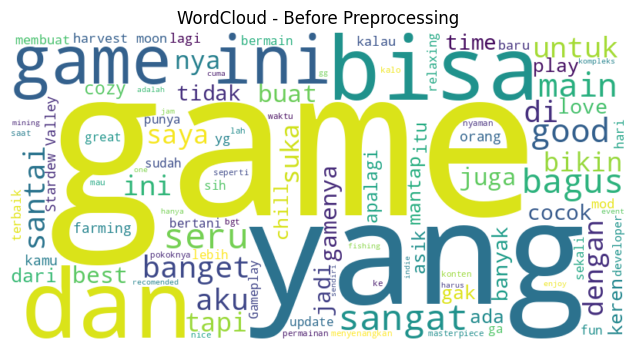

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_before = ' '.join(df['Reviews'].dropna().astype(str))
wordcloud_before = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text_before)

plt.figure(figsize=(10, 4))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Before Preprocessing')
plt.show()

Pada bagian ini kita membuat WordCloud untuk melihat kata-kata yang paling sering muncul dalam review Stardew Valley. Semakin besar ukuran suatu kata pada WordCloud, semakin sering kata tersebut muncul dalam data review. Visualisasi ini digunakan untuk melihat gambaran umum isi review sebelum dilakukan preprocessing.

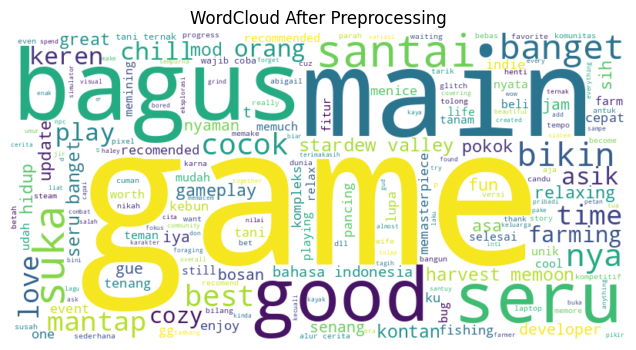

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ngegabungin seluruh teks hasil preprocessing
text_after = ' '.join(df['prepro'].dropna().astype(str))
wordcloud_after = WordCloud(width=800, height=400, background_color='white').generate(text_after)

plt.figure(figsize=(10, 4))
plt.imshow(wordcloud_after, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud After Preprocessing')
plt.show()

Pada bagian ini kita membuat WordCloud setelah preprocessing untuk melihat kata-kata yang masih muncul setelah teks dibersihkan. Visualisasi ini dapat digunakan untuk melihat perubahan kata-kata yang muncul sebelum dan setelah preprocessing.

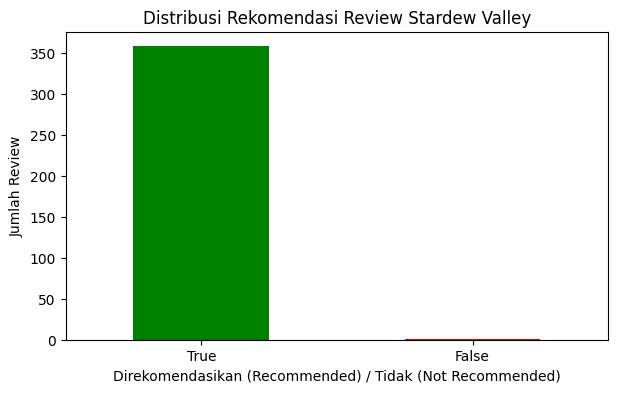

In [42]:
plt.figure(figsize=(7, 4))
df['Voted_up'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribusi Rekomendasi Review Stardew Valley')
plt.xlabel('Direkomendasikan (Recommended) / Tidak (Not Recommended)')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.show()

Pada bagian ini kita membuat grafik untuk melihat distribusi rekomendasi dari review Stardew Valley berdasarkan kolom Voted_up. "Recommended" menunjukkan review yang direkomendasikan oleh pengguna, sedangkan "Not Recommended" menunjukkan review yang tidak direkomendasikan. Hasilnya kemudian ditampilkan dalam bentuk grafik agar perbandingan jumlah kedua kategori lebih mudah dilihat.

In [43]:
df.to_csv('steam_reviews_preprocessed.csv', index=False)

And the lasttt, pada bagian ini kita menyimpan data hasil preprocessing ke dalam file CSV dengan nama steam_reviews_preprocessed.csv.